In [1]:
!pip -q install -U \
unsloth \
peft \
datasets \
scikit-learn \
pandas \
matplotlib \
tqdm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.7/75.7 kB 1.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 4.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 5.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.8/84.8 MB 22.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 775.8/775.8 kB 38.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.8/506.8 kB 27.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 105.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.0/11.0 MB 98.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 104.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.2/80.2 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.0/41.0 MB 49.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1

In [2]:
import os

os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

import gc
import glob
import json
import random
import warnings
import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

from datasets import load_dataset
from unsloth import FastLanguageModel

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_recall_fscore_support,
    confusion_matrix,
    classification_report,
)

from tqdm.auto import tqdm

warnings.filterwarnings("ignore")

# ============================================================
# Reproducibility
# ============================================================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True
torch.set_float32_matmul_precision("high")

print("=" * 70)
print("Torch :", torch.__version__)
print("CUDA  :", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU count:", torch.cuda.device_count())
    for i in range(torch.cuda.device_count()):
        print(f"  GPU {i}: {torch.cuda.get_device_name(i)}, "
              f"{round(torch.cuda.get_device_properties(i).total_memory / 1024**3, 2)} GB")
    print("CUDA  :", torch.version.cuda)

print("=" * 70)

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
Torch : 2.10.0+cu128
CUDA  : True
GPU count: 2
  GPU 0: Tesla T4, 14.56 GB
  GPU 1: Tesla T4, 14.56 GB
CUDA  : 12.8


In [3]:
BASE_MODEL = "unsloth/Meta-Llama-3.1-8B"
MAX_SEQ_LENGTH = 4096
MAX_TRAIN_SAMPLES_PER_EPOCH = 5000
TRAIN_MAX_LENGTH = 1536
LOAD_IN_4BIT = True
DTYPE = None

PRIMEVUL_PROMPTS_PATH = "/kaggle/input/datasets/abeerch/pv-main/primevul_train_processed_no_label.jsonl"
PRIMEVUL_LABELS_PATH  = "/kaggle/input/datasets/abeerch/pv-main/primevul_train_labels.json"

TRAIN_SPLIT = 0.80
VAL_SPLIT   = 0.10
TEST_SPLIT  = 0.10

VULN_RATIO_TRAIN = 0.50

LORA_RANK = 16
LORA_ALPHA = 8
LORA_DROPOUT = 0.05
TARGET_MODULES = ["q_proj", "k_proj", "v_proj", "o_proj"]

HEAD_HIDDEN_DIM = 256
HEAD_DROPOUT = 0.1
POOLING = "mean"

EPOCHS = 3
EFFECTIVE_BATCH_SIZE = 16
PHYSICAL_BATCH_SIZE = 1
GRAD_ACCUM = 16
LEARNING_RATE = 2e-4
WEIGHT_DECAY = 0.01
EARLY_STOPPING_PATIENCE = 2

GRAD_CLIP_NORM = 1.0
WARMUP_RATIO = 0.06
USE_FOCAL_LOSS = True
FOCAL_GAMMA = 2.0

EVAL_BATCH_SIZE = 16

LOG_EVERY_N_STEPS = 50
SAVE_EVERY_N_STEPS = 500

VAL_MONITOR_SIZE = 1500
THRESH_TUNE_SIZE = 3000

FEATURE_CACHE_DIR = "./primevul_features_v2"
EXPERIMENT_NAME = "primevul_qlora_classifier_v2"

# ============================================================
# Multi-session control
#   RESUME_FROM_CHECKPOINT — False for the first file (fresh start),
#                              True for the second file (continue).
#   STOP_AFTER_EPOCH — the training loop halts itself right after this
#                        epoch's state is saved. None = run to EPOCHS
#                        (or until early stopping). This removes the
#                        need to manually watch logs and kill the kernel.
# ============================================================
RESUME_FROM_CHECKPOINT = True
RESUME_MODEL_DIR = None
STOP_AFTER_EPOCH = None

if RESUME_FROM_CHECKPOINT:
    if RESUME_MODEL_DIR is not None:
        FINAL_MODEL_DIR = RESUME_MODEL_DIR
        RUN_TIMESTAMP = os.path.basename(FINAL_MODEL_DIR).replace(f"{EXPERIMENT_NAME}_", "")
    else:
        state_files = sorted(glob.glob("./saved_models/*/training_state.json"), key=os.path.getmtime)
        if state_files:
            FINAL_MODEL_DIR = os.path.dirname(state_files[-1])
            RUN_TIMESTAMP = os.path.basename(FINAL_MODEL_DIR).replace(f"{EXPERIMENT_NAME}_", "")
        else:
            # Nothing local yet — likely a fresh session where checkpoints only exist
            # in a read-only Kaggle input dataset. A later cell (checkpoint copy step)
            # is expected to copy them in and override FINAL_MODEL_DIR before training.
            print("[config] No local training_state.json found yet — expecting a later "
                  "cell to copy checkpoints in from a Kaggle input dataset.")
            RUN_TIMESTAMP = "pending_resume"
            FINAL_MODEL_DIR = f"./saved_models/{EXPERIMENT_NAME}_{RUN_TIMESTAMP}"
else:
    RUN_TIMESTAMP = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
    FINAL_MODEL_DIR = f"./saved_models/{EXPERIMENT_NAME}_{RUN_TIMESTAMP}"

os.makedirs(FINAL_MODEL_DIR, exist_ok=True)

print("=" * 70)
print("Pipeline 1 v2 — QLoRA + Classification Head Config Loaded")
print("=" * 70)
print(f"Train max length : {TRAIN_MAX_LENGTH}")
print(f"Epochs           : {EPOCHS} (patience {EARLY_STOPPING_PATIENCE})")
print(f"Physical batch   : {PHYSICAL_BATCH_SIZE}  (accum {GRAD_ACCUM})")
print(f"Loss             : {'Focal (gamma=' + str(FOCAL_GAMMA) + ', no pos_weight)' if USE_FOCAL_LOSS else 'Plain BCE'}")
print(f"Resampling       : dynamic per-epoch, proportional 50/50 balance (capped at {MAX_TRAIN_SAMPLES_PER_EPOCH}/epoch)")
print(f"Grad clip norm   : {GRAD_CLIP_NORM}")
print(f"LR warmup ratio  : {WARMUP_RATIO}")
print(f"Resume mode      : {'ON — continuing ' + FINAL_MODEL_DIR if RESUME_FROM_CHECKPOINT else 'OFF — fresh run'}")
print(f"Stop after epoch : {STOP_AFTER_EPOCH if STOP_AFTER_EPOCH is not None else 'not set — run to completion'}")
print(f"Final model dir  : {FINAL_MODEL_DIR}")
print("=" * 70)

[config] No local training_state.json found yet — expecting a later cell to copy checkpoints in from a Kaggle input dataset.
Pipeline 1 v2 — QLoRA + Classification Head Config Loaded
Train max length : 1536
Epochs           : 3 (patience 2)
Physical batch   : 1  (accum 16)
Loss             : Focal (gamma=2.0, no pos_weight)
Resampling       : dynamic per-epoch, proportional 50/50 balance (capped at 5000/epoch)
Grad clip norm   : 1.0
LR warmup ratio  : 0.06
Resume mode      : ON — continuing ./saved_models/primevul_qlora_classifier_v2_pending_resume
Stop after epoch : not set — run to completion
Final model dir  : ./saved_models/primevul_qlora_classifier_v2_pending_resume


In [4]:
# ============================================================
# Copy resume checkpoint from read-only Kaggle input dataset
# into a writable local directory
# ============================================================
import shutil, glob

KAGGLE_INPUT_BASE = "/kaggle/input/datasets/abeerch/saved-train/saved_models"

if RESUME_FROM_CHECKPOINT and os.path.exists(KAGGLE_INPUT_BASE):
    candidates = glob.glob(f"{KAGGLE_INPUT_BASE}/primevul_qlora_classifier_v2_*")
    assert candidates, f"No checkpoint folder found under {KAGGLE_INPUT_BASE}"
    KAGGLE_INPUT_CHECKPOINT_DIR = sorted(candidates)[-1]
    print(f"[resume] Found checkpoint source: {KAGGLE_INPUT_CHECKPOINT_DIR}")

    writable_dir = f"./saved_models/{EXPERIMENT_NAME}_resumed"
    if not os.path.exists(writable_dir):
        shutil.copytree(KAGGLE_INPUT_CHECKPOINT_DIR, writable_dir)
        print(f"[resume] Copied checkpoint -> {writable_dir}")
    else:
        print(f"[resume] Writable copy already exists at {writable_dir}, skipping copy.")

    FINAL_MODEL_DIR = writable_dir
    RUN_TIMESTAMP = "resumed"

    print(f"[resume] Using writable checkpoint dir: {FINAL_MODEL_DIR}")
    print(f"[resume] Contents: {os.listdir(FINAL_MODEL_DIR)}")

    required = ["training_state.json", "lora_adapter_latest", "head_latest.pt"]
    missing = [r for r in required if not os.path.exists(f"{FINAL_MODEL_DIR}/{r}")]
    if missing:
        print(f"[resume] WARNING — missing required files/folders: {missing}")

[resume] Found checkpoint source: /kaggle/input/datasets/abeerch/saved-train/saved_models/primevul_qlora_classifier_v2_20260818_034418
[resume] Copied checkpoint -> ./saved_models/primevul_qlora_classifier_v2_resumed
[resume] Using writable checkpoint dir: ./saved_models/primevul_qlora_classifier_v2_resumed
[resume] Contents: ['lora_adapter_latest', 'head_latest.pt', 'head_best.pt', 'lora_adapter_best', 'training_state.json']


In [5]:
# ============================================================
# Load Llama-3.1-8B BASE + Apply QLoRA — SINGLE GPU
# ============================================================

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name=BASE_MODEL,
    max_seq_length=MAX_SEQ_LENGTH,
    dtype=DTYPE,
    load_in_4bit=LOAD_IN_4BIT,
    device_map={"": torch.cuda.current_device()},
)

model.config.use_cache = False

model = FastLanguageModel.get_peft_model(
    model,
    r=LORA_RANK,
    target_modules=TARGET_MODULES,
    lora_alpha=LORA_ALPHA,
    lora_dropout=LORA_DROPOUT,
    bias="none",
    use_gradient_checkpointing="unsloth",
    random_state=SEED,
)

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "right"

print("=" * 70)
print("Base Model + LoRA Loaded (single GPU)")
print("=" * 70)
model.print_trainable_parameters()
print(f"Model device: {next(model.parameters()).device}")
print("=" * 70)

==((====))==  Unsloth 2026.8.18: Fast Llama patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 2. Max memory: 14.562 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

Unsloth: Will load unsloth/meta-llama-3.1-8b-unsloth-bnb-4bit as a legacy tokenizer.
Unsloth: Dropout = 0 is supported for fast patching. You are using dropout = 0.05.
Unsloth will patch all other layers, except LoRA matrices, causing a performance hit.
Unsloth 2026.8.18 patched 32 layers with 0 QKV layers, 0 O layers and 0 MLP layers.


Base Model + LoRA Loaded (single GPU)
trainable params: 13,631,488 || all params: 8,043,892,736 || trainable%: 0.1695
Model device: cuda:0


In [6]:
# ============================================================
# Load Full PrimeVul Dataset — labels from separate file, positional join
# ============================================================

primevul_dataset = load_dataset("json", data_files=PRIMEVUL_PROMPTS_PATH, split="train")

with open(PRIMEVUL_LABELS_PATH, "r") as f:
    label_list = json.load(f)

assert len(label_list) == len(primevul_dataset), (
    f"Mismatch: {len(primevul_dataset)} rows vs {len(label_list)} labels — "
    "row alignment is broken, do not proceed until these match."
)

LABEL_NAMES = {0: "Safe", 1: "Vulnerable"}

def attach_label(example, idx):
    example["label"] = int(label_list[idx])
    return example

primevul_dataset = primevul_dataset.map(attach_label, with_indices=True)

print("=" * 70)
print(f"Total: {len(primevul_dataset)}")
label_counts = pd.Series(primevul_dataset["label"]).value_counts().sort_index()
for lbl, count in label_counts.items():
    print(f"  {LABEL_NAMES[lbl]:<12}: {count} ({100*count/len(primevul_dataset):.2f}%)")
print("=" * 70)

Generating train split: 0 examples [00:00, ? examples/s]

Map:   0%|          | 0/175797 [00:00<?, ? examples/s]

Total: 175797
  Safe        : 170935 (97.23%)
  Vulnerable  : 4862 (2.77%)


In [7]:
# ============================================================
# Build Flat Prompt Text — Base model has no chat template,
# so system+user content is concatenated into one plain block.
# ============================================================

def format_base_prompt(examples):
    texts = []
    for messages in examples["messages"]:
        parts = [m["content"] for m in messages]
        flat = "\n\n".join(parts) + "\n\nLabel:"
        texts.append(flat)
    return {"text": texts}

primevul_dataset = primevul_dataset.map(format_base_prompt, batched=True)

print("=" * 70)
print("Flat Prompt Example")
print("=" * 70)
print(primevul_dataset[0]["text"][:1000])
print("=" * 70)

Map:   0%|          | 0/175797 [00:00<?, ? examples/s]

Flat Prompt Example
You are an expert cybersecurity analyst specializing in static source code security analysis.

Your objective is to analyze the provided source code and determine whether it contains a security vulnerability.

Instructions:
- Analyze only the provided source code.
- Do not rely on assumptions outside the given code.
- Do not infer vulnerabilities from project names, file names, commit messages, CVEs, or any external metadata.
- Carefully inspect control flow, data flow, memory operations, pointer usage, resource management, authentication, authorization, input validation, cryptographic usage, and other security-sensitive constructs.
- If any exploitable security vulnerability exists, classify the code as Vulnerable.
- Otherwise classify it as Safe.

This is a binary classification task.

Analyze the following source code and determine whether it contains a security vulnerability.

Return ONLY the classification.

Possible labels:
- Safe
- Vulnerable

Source Code:

l

In [8]:
# ============================================================
# Train / Validation / Test Split (stratified) — natural imbalance
# preserved in ALL three splits; rebalancing happens only to train, next cell.
# ============================================================

indices = list(range(len(primevul_dataset)))
labels_all = primevul_dataset["label"]

train_idx, remaining_idx = train_test_split(
    indices,
    test_size=(1 - TRAIN_SPLIT),
    stratify=[labels_all[i] for i in indices],
    random_state=SEED,
)

val_ratio = VAL_SPLIT / (VAL_SPLIT + TEST_SPLIT)
val_idx, test_idx = train_test_split(
    remaining_idx,
    test_size=(1 - val_ratio),
    stratify=[labels_all[i] for i in remaining_idx],
    random_state=SEED,
)

pv_train = primevul_dataset.select(train_idx)
pv_val   = primevul_dataset.select(val_idx)
pv_test  = primevul_dataset.select(test_idx)

print("=" * 70)
print(f"Training Samples   : {len(pv_train)} ({TRAIN_SPLIT*100:.0f}%)")
print(f"Validation Samples : {len(pv_val)} ({VAL_SPLIT*100:.0f}%)")
print(f"Test Samples       : {len(pv_test)} ({TEST_SPLIT*100:.0f}%)")
print("=" * 70)

Training Samples   : 140637 (80%)
Validation Samples : 17580 (10%)
Test Samples       : 17580 (10%)


In [9]:
train_labels_arr = np.array(pv_train["label"])
vuln_idx_train_pool = np.where(train_labels_arr == 1)[0]
safe_idx_train_pool = np.where(train_labels_arr == 0)[0]
rng = np.random.default_rng(SEED)   # required by the final evaluation cell's balanced-test-subset construction

def resample_train_epoch(epoch_num):
    n_vuln = len(vuln_idx_train_pool)
    n_safe_needed = int(round(n_vuln * (1 - VULN_RATIO_TRAIN) / VULN_RATIO_TRAIN))
    n_safe_needed = min(n_safe_needed, len(safe_idx_train_pool))
    epoch_rng = np.random.default_rng(SEED + epoch_num)

    if MAX_TRAIN_SAMPLES_PER_EPOCH is not None and (n_vuln + n_safe_needed) > MAX_TRAIN_SAMPLES_PER_EPOCH:
        # Scale BOTH classes down proportionally — keeps the 50/50 balance
        # intact even when capped. (The alternative — keeping all Vulnerable
        # and only capping Safe — was tried and made results worse: it skews
        # the in-batch ratio to ~78/22 Vuln/Safe, which biases the model
        # toward over-predicting Vulnerable.)
        scale = MAX_TRAIN_SAMPLES_PER_EPOCH / (n_vuln + n_safe_needed)
        n_vuln_capped = max(1, int(n_vuln * scale))
        n_safe_capped = MAX_TRAIN_SAMPLES_PER_EPOCH - n_vuln_capped
        sampled_vuln = epoch_rng.choice(vuln_idx_train_pool, size=n_vuln_capped, replace=False)
        sampled_safe = epoch_rng.choice(safe_idx_train_pool, size=n_safe_capped, replace=False)
        combined = np.concatenate([sampled_vuln, sampled_safe])
    else:
        sampled_safe = epoch_rng.choice(safe_idx_train_pool, size=n_safe_needed, replace=False)
        combined = np.concatenate([vuln_idx_train_pool, sampled_safe])

    epoch_rng.shuffle(combined)
    return pv_train.select(combined.tolist())

# Preview the actual per-epoch composition given the cap
_n_safe_preview = min(
    int(round(len(vuln_idx_train_pool) * (1 - VULN_RATIO_TRAIN) / VULN_RATIO_TRAIN)),
    len(safe_idx_train_pool),
)
_n_vuln_preview = len(vuln_idx_train_pool)
if MAX_TRAIN_SAMPLES_PER_EPOCH is not None and (_n_vuln_preview + _n_safe_preview) > MAX_TRAIN_SAMPLES_PER_EPOCH:
    _scale_preview = MAX_TRAIN_SAMPLES_PER_EPOCH / (_n_vuln_preview + _n_safe_preview)
    _n_vuln_preview = max(1, int(_n_vuln_preview * _scale_preview))
    _n_safe_preview = MAX_TRAIN_SAMPLES_PER_EPOCH - _n_vuln_preview

print("=" * 70)
print(f"Train pools defined — Vulnerable: {len(vuln_idx_train_pool)}, Safe pool: {len(safe_idx_train_pool)}")
print(f"Each epoch draws {_n_vuln_preview} Vulnerable + {_n_safe_preview} Safe "
      f"= {_n_vuln_preview + _n_safe_preview} samples/epoch (proportionally balanced)")
print(f"Val (natural): {len(pv_val)}   Test (natural): {len(pv_test)}")
print("=" * 70)

Train pools defined — Vulnerable: 3890, Safe pool: 136747
Each epoch draws 2500 Vulnerable + 2500 Safe = 5000 samples/epoch (proportionally balanced)
Val (natural): 17580   Test (natural): 17580


In [10]:
val_labels_arr_full = np.array(pv_val["label"])
val_idx_all = np.arange(len(pv_val))
val_monitor_idx, _ = train_test_split(
    val_idx_all, train_size=min(VAL_MONITOR_SIZE, len(pv_val)),
    stratify=val_labels_arr_full, random_state=SEED,
)
pv_val_monitor = pv_val.select(val_monitor_idx.tolist())
print(f"Validation monitoring subset: {len(pv_val_monitor)} samples (stratified from {len(pv_val)})")

Validation monitoring subset: 1500 samples (stratified from 17580)


In [11]:
RUN_SANITY_CHECK = False 

if RUN_SANITY_CHECK:
    vuln_idx_train_pool_full = vuln_idx_train_pool
    safe_idx_train_pool_full = safe_idx_train_pool
    pv_val_monitor_full = pv_val_monitor
    vuln_idx_train_pool = vuln_idx_train_pool[:150]
    safe_idx_train_pool = safe_idx_train_pool[:150]
    pv_val_monitor = pv_val_monitor.select(range(min(200, len(pv_val_monitor))))
    print(f"Sanity check active — pools shrunk to {len(vuln_idx_train_pool)}+{len(safe_idx_train_pool)}, val {len(pv_val_monitor)}.")
else:
    if "vuln_idx_train_pool_full" in dir():
        vuln_idx_train_pool = vuln_idx_train_pool_full
        safe_idx_train_pool = safe_idx_train_pool_full
        pv_val_monitor = pv_val_monitor_full
    print(f"Full pools in use — Vuln {len(vuln_idx_train_pool)}, Safe pool {len(safe_idx_train_pool)}, val {len(pv_val_monitor)}.")

Full pools in use — Vuln 3890, Safe pool 136747, val 1500.


In [12]:
# ============================================================
# Joint Model — LoRA-adapted backbone + classification head,
# trained end-to-end. Device-aware for multi-GPU (device_map="auto").
# ============================================================

class LlamaClassifier(nn.Module):
    def __init__(self, peft_model, hidden_size, head_hidden_dim=256, dropout=0.1):
        super().__init__()
        # peft_model.model = LlamaForCausalLM (LoRA-injected); .model again = LlamaModel body,
        # bypassing lm_head entirely.
        self.backbone = peft_model.model.model
        self.classifier = nn.Sequential(
            nn.Linear(hidden_size, head_hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(head_hidden_dim, 1),
        )
        self.input_device = next(self.backbone.parameters()).device

    def forward(self, input_ids, attention_mask):
        input_ids = input_ids.to(self.input_device)
        attention_mask = attention_mask.to(self.input_device)
        outputs = self.backbone(input_ids=input_ids, attention_mask=attention_mask)
        hidden = outputs.last_hidden_state
        mask = attention_mask.unsqueeze(-1).float()
        pooled = (hidden * mask).sum(1) / mask.sum(1).clamp(min=1e-6)
        pooled = pooled.to(next(self.classifier.parameters()).device)
        logits = self.classifier(pooled).squeeze(-1)
        return logits


classifier_model = LlamaClassifier(
    model,
    hidden_size=model.config.hidden_size,
    head_hidden_dim=HEAD_HIDDEN_DIM,
    dropout=HEAD_DROPOUT,
).to(next(model.parameters()).device)

trainable = sum(p.numel() for p in classifier_model.parameters() if p.requires_grad)
print("=" * 70)
print(f"Joint model built — trainable parameters (LoRA + head): {trainable}")
print("=" * 70)

Joint model built — trainable parameters (LoRA + head): 14680577


In [13]:
# ============================================================
# Timing probe — run 30 real training steps, extrapolate full epoch time
import time
import torch.nn.functional as F

def focal_loss_probe(logits, targets, gamma=2.0):
    bce = F.binary_cross_entropy_with_logits(logits, targets, reduction="none")
    probs = torch.sigmoid(logits)
    pt = torch.where(targets == 1, probs, 1 - probs)
    focal_term = (1 - pt).clamp(min=1e-6) ** gamma
    return (focal_term * bce).mean()

def batch_forward_probe(texts, labels_batch):
    encoded = tokenizer(
        texts, return_tensors="pt", padding=True, truncation=True, max_length=TRAIN_MAX_LENGTH
    )
    labels_tensor = torch.tensor(labels_batch, dtype=torch.float32).to(classifier_model.input_device)
    logits = classifier_model(encoded["input_ids"], encoded["attention_mask"])
    return logits, labels_tensor

probe_optimizer = torch.optim.AdamW(
    [p for p in classifier_model.parameters() if p.requires_grad],
    lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY,
)

probe_epoch_data = resample_train_epoch(0)
n_probe_samples = 30 * PHYSICAL_BATCH_SIZE
probe_texts = probe_epoch_data["text"][:n_probe_samples]
probe_labels = probe_epoch_data["label"][:n_probe_samples]

classifier_model.train()
t0 = time.time()
for i in range(0, len(probe_texts), PHYSICAL_BATCH_SIZE):
    bt = probe_texts[i:i + PHYSICAL_BATCH_SIZE]
    bl = probe_labels[i:i + PHYSICAL_BATCH_SIZE]
    logits, labels_t = batch_forward_probe(bt, bl)
    loss = focal_loss_probe(logits, labels_t, gamma=FOCAL_GAMMA) / GRAD_ACCUM
    loss.backward()
    if (i // PHYSICAL_BATCH_SIZE + 1) % GRAD_ACCUM == 0:
        probe_optimizer.step()
        probe_optimizer.zero_grad()
elapsed = time.time() - t0

probe_optimizer.zero_grad()  # discard partial accumulation from the probe

steps_run = len(probe_texts) // PHYSICAL_BATCH_SIZE
sec_per_step = elapsed / steps_run
steps_per_epoch_est = (len(vuln_idx_train_pool) * 2) // PHYSICAL_BATCH_SIZE
est_epoch_hours = (sec_per_step * steps_per_epoch_est) / 3600

print("=" * 70)
print(f"Measured: {sec_per_step:.2f} sec/step over {steps_run} steps")
print(f"Estimated full epoch time: {est_epoch_hours:.1f} hours ({steps_per_epoch_est} steps)")
print(f"Estimated {EPOCHS}-epoch total: {est_epoch_hours*EPOCHS:.1f} hours")
print("=" * 70)

del probe_optimizer
torch.cuda.empty_cache()

`use_return_dict` is deprecated! Use `return_dict` instead!


Unsloth: Will smartly offload gradients to save VRAM!
Unsloth: Double buffering enabled (parallel H2D + compute) for backward pass.
Measured: 2.21 sec/step over 30 steps
Estimated full epoch time: 4.8 hours (7780 steps)
Estimated 3-epoch total: 14.3 hours


## How to run this across two Kaggle sessions

**Session 1 (fresh start):**
1. In Cell 2, leave `RESUME_FROM_CHECKPOINT = False`.
2. Run Cells 0 through 12 normally.
3. Training will print `[state] saved training_state.json — epoch N complete. Safe to stop the session now if needed.` after every epoch.
4. Once you see that message after **epoch 2** (or whenever you're getting close to the 12-hour limit), you can manually stop/end the session — everything needed to continue is already saved to disk under `FINAL_MODEL_DIR` (printed by Cell 2's output).
5. Note down that `FINAL_MODEL_DIR` path (or don't worry about it — auto-detect in Session 2 will find it).

**Session 2 (continue):**
1. In Cell 2, set `RESUME_FROM_CHECKPOINT = True`. Leave `RESUME_MODEL_DIR = None` unless you have multiple prior runs saved and need to point at a specific one.
2. Run Cells 0 through 12 again from the top — Cells 3–10 rebuild the model/data/pools exactly as before (fast, a few minutes), and Cell 12 will detect the saved state and continue from the next epoch, with the LR schedule fast-forwarded to the correct position.
3. Once training finishes (or early-stops), continue on to the threshold tuning and evaluation cells as normal — no changes needed there.

One honest caveat: Adam's momentum/variance state isn't persisted across sessions (only model weights and the LR schedule position are) — each resumed epoch starts with fresh optimizer momentum. This is a minor "warm restart" effect, not a correctness problem, for a handful of epochs.

In [14]:
# ============================================================
# Joint Training — LoRA backbone + head, dynamic per-epoch resampling
# (proportional 50/50 balance), focal loss (no pos_weight — batches
# already balanced), LR warmup+decay, gradient clipping, PR-AUC-based
# checkpoint selection. Supports multi-session resume via
# training_state.json, and a self-stopping STOP_AFTER_EPOCH control.
# ============================================================

import torch.nn.functional as F
from sklearn.metrics import average_precision_score
from torch.optim.lr_scheduler import LambdaLR

TRAINING_STATE_PATH = f"{FINAL_MODEL_DIR}/training_state.json"

def batch_forward(texts, labels_batch):
    encoded = tokenizer(
        texts, return_tensors="pt", padding=True, truncation=True, max_length=TRAIN_MAX_LENGTH
    )
    labels_tensor = torch.tensor(labels_batch, dtype=torch.float32).to(classifier_model.input_device)
    logits = classifier_model(encoded["input_ids"], encoded["attention_mask"])
    return logits, labels_tensor


def focal_loss_with_logits(logits, targets, gamma=2.0):
    bce = F.binary_cross_entropy_with_logits(logits, targets, reduction="none")
    probs = torch.sigmoid(logits)
    pt = torch.where(targets == 1, probs, 1 - probs)
    focal_term = (1 - pt).clamp(min=1e-6) ** gamma
    return (focal_term * bce).mean()


bce_criterion = nn.BCEWithLogitsLoss()

optimizer = torch.optim.AdamW(
    [p for p in classifier_model.parameters() if p.requires_grad],
    lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY,
)

trainable_params = [p for p in classifier_model.parameters() if p.requires_grad]

# Step count based on the ACTUAL per-epoch sample count under proportional
# scaling — matches resample_train_epoch's real output, so the LR schedule
# fully decays by the end of training instead of stalling partway.
n_vuln_actual = len(vuln_idx_train_pool)
n_safe_actual = min(
    int(round(n_vuln_actual * (1 - VULN_RATIO_TRAIN) / VULN_RATIO_TRAIN)),
    len(safe_idx_train_pool),
)
if MAX_TRAIN_SAMPLES_PER_EPOCH is not None and (n_vuln_actual + n_safe_actual) > MAX_TRAIN_SAMPLES_PER_EPOCH:
    _scale = MAX_TRAIN_SAMPLES_PER_EPOCH / (n_vuln_actual + n_safe_actual)
    n_vuln_actual = max(1, int(n_vuln_actual * _scale))
    n_safe_actual = MAX_TRAIN_SAMPLES_PER_EPOCH - n_vuln_actual
actual_samples_per_epoch = n_vuln_actual + n_safe_actual

steps_per_epoch = actual_samples_per_epoch // PHYSICAL_BATCH_SIZE // GRAD_ACCUM
total_optimizer_steps = steps_per_epoch * EPOCHS
warmup_steps = max(1, int(WARMUP_RATIO * total_optimizer_steps))

def lr_lambda(step):
    if step < warmup_steps:
        return step / warmup_steps
    progress = (step - warmup_steps) / max(1, total_optimizer_steps - warmup_steps)
    return max(0.0, 0.5 * (1 + np.cos(np.pi * progress)))

scheduler = LambdaLR(optimizer, lr_lambda)

val_texts = pv_val_monitor["text"]
val_labels_list = pv_val_monitor["label"]

# ---- Resume state (overwritten below if RESUME_FROM_CHECKPOINT and a saved state exists) ----
start_epoch = 1
best_val_ap = -1.0
best_epoch = -1
epochs_without_improvement = 0
history = []
global_opt_step = 0

if RESUME_FROM_CHECKPOINT and os.path.exists(TRAINING_STATE_PATH):
    with open(TRAINING_STATE_PATH, "r") as f:
        state = json.load(f)
    start_epoch = state["last_completed_epoch"] + 1
    best_val_ap = state["best_val_ap"]
    best_epoch = state["best_epoch"]
    epochs_without_improvement = state["epochs_without_improvement"]
    history = state["history"]
    global_opt_step = state["global_opt_step"]

    model.load_adapter(f"{FINAL_MODEL_DIR}/lora_adapter_latest", adapter_name="default")
    classifier_model.classifier.load_state_dict(torch.load(f"{FINAL_MODEL_DIR}/head_latest.pt"))

    for _ in range(global_opt_step):
        scheduler.step()   # fast-forward the LR schedule to where it left off (cheap, no compute)

    print(f"[resume] Continuing from epoch {start_epoch} | global_opt_step {global_opt_step} | "
          f"best so far: epoch {best_epoch} (val_ap {best_val_ap:.4f})")
    print("[resume] NOTE: Adam optimizer momentum is NOT restored across sessions "
          "(fresh momentum this session — minor warm-restart effect only).")
elif RESUME_FROM_CHECKPOINT:
    print("[resume] RESUME_FROM_CHECKPOINT=True but no training_state.json found — starting fresh.")
else:
    print("Starting fresh training run (no resume).")

if start_epoch > EPOCHS:
    print(f"All {EPOCHS} epochs already completed per saved state — nothing to train. "
          f"Proceed to the threshold tuning / evaluation cells.")

for epoch in range(start_epoch, EPOCHS + 1):
    pv_train_epoch = resample_train_epoch(epoch)
    train_texts = pv_train_epoch["text"]
    train_labels_list = pv_train_epoch["label"]
    print(f"[epoch {epoch}] resampled train set: {len(train_texts)} samples", flush=True)

    classifier_model.train()
    perm = np.random.permutation(len(train_texts))
    train_loss_total = 0.0
    optimizer.zero_grad()

    for step, start in enumerate(tqdm(range(0, len(perm), PHYSICAL_BATCH_SIZE), desc=f"Epoch {epoch}")):
        batch_idx = perm[start:start + PHYSICAL_BATCH_SIZE]
        batch_texts = [train_texts[i] for i in batch_idx]
        batch_labels = [train_labels_list[i] for i in batch_idx]

        logits, labels_t = batch_forward(batch_texts, batch_labels)
        if USE_FOCAL_LOSS:
            loss = focal_loss_with_logits(logits, labels_t, gamma=FOCAL_GAMMA) / GRAD_ACCUM
        else:
            loss = bce_criterion(logits, labels_t) / GRAD_ACCUM
        loss.backward()
        train_loss_total += loss.item() * GRAD_ACCUM * len(batch_idx)

        if (step + 1) % GRAD_ACCUM == 0:
            torch.nn.utils.clip_grad_norm_(trainable_params, max_norm=GRAD_CLIP_NORM)
            optimizer.step()
            scheduler.step()
            optimizer.zero_grad()
            global_opt_step += 1

        if (step + 1) % LOG_EVERY_N_STEPS == 0:
            running_avg = train_loss_total / ((step + 1) * PHYSICAL_BATCH_SIZE)
            current_lr = scheduler.get_last_lr()[0]
            print(f"  step {step+1}/{len(perm)//PHYSICAL_BATCH_SIZE} | running_loss {running_avg:.4f} | lr {current_lr:.2e}", flush=True)

        if (step + 1) % SAVE_EVERY_N_STEPS == 0:
            model.save_pretrained(f"{FINAL_MODEL_DIR}/lora_adapter_latest")
            torch.save(classifier_model.classifier.state_dict(), f"{FINAL_MODEL_DIR}/head_latest.pt")
            print(f"  [checkpoint] saved at step {step+1}", flush=True)

    if (len(perm) // PHYSICAL_BATCH_SIZE) % GRAD_ACCUM != 0:
        torch.nn.utils.clip_grad_norm_(trainable_params, max_norm=GRAD_CLIP_NORM)
        optimizer.step()
        scheduler.step()
        optimizer.zero_grad()

    train_loss_avg = train_loss_total / len(train_texts)

    print(f"  [val] starting validation on {len(val_texts)} samples...", flush=True)
    classifier_model.eval()
    val_probs, val_true = [], []
    with torch.no_grad():
        for vstep, start in enumerate(range(0, len(val_texts), EVAL_BATCH_SIZE)):
            batch_texts = val_texts[start:start + EVAL_BATCH_SIZE]
            batch_labels = val_labels_list[start:start + EVAL_BATCH_SIZE]
            logits, labels_t = batch_forward(batch_texts, batch_labels)
            probs = torch.sigmoid(logits).cpu().numpy()
            val_probs.extend(probs)
            val_true.extend(batch_labels)
            if (vstep + 1) % 50 == 0:
                print(f"  [val] {vstep+1}/{len(val_texts)//EVAL_BATCH_SIZE} batches", flush=True)

    val_preds_05 = (np.array(val_probs) > 0.5).astype(int)
    val_acc = accuracy_score(val_true, val_preds_05)
    val_prec, val_rec, val_f1, _ = precision_recall_fscore_support(val_true, val_preds_05, average="binary", zero_division=0)
    val_ap = average_precision_score(val_true, val_probs)

    history.append({
        "epoch": epoch, "train_loss": train_loss_avg,
        "val_acc": val_acc, "val_precision": val_prec, "val_recall": val_rec,
        "val_f1": val_f1, "val_ap": val_ap,
    })

    print(f"Epoch {epoch}/{EPOCHS} | train_loss {train_loss_avg:.4f} | "
          f"val_acc {val_acc:.4f} | val_prec {val_prec:.4f} | val_rec {val_rec:.4f} | "
          f"val_f1 {val_f1:.4f} | val_AP {val_ap:.4f}", flush=True)

    if val_ap > best_val_ap:
        best_val_ap = val_ap
        best_epoch = epoch
        model.save_pretrained(f"{FINAL_MODEL_DIR}/lora_adapter_best")
        torch.save(classifier_model.classifier.state_dict(), f"{FINAL_MODEL_DIR}/head_best.pt")
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1

    model.save_pretrained(f"{FINAL_MODEL_DIR}/lora_adapter_latest")
    torch.save(classifier_model.classifier.state_dict(), f"{FINAL_MODEL_DIR}/head_latest.pt")

    with open(TRAINING_STATE_PATH, "w") as f:
        json.dump({
            "last_completed_epoch": epoch,
            "best_val_ap": best_val_ap,
            "best_epoch": best_epoch,
            "epochs_without_improvement": epochs_without_improvement,
            "history": history,
            "global_opt_step": global_opt_step,
        }, f, indent=2)
    print(f"  [state] saved training_state.json — epoch {epoch} complete.", flush=True)

    if STOP_AFTER_EPOCH is not None and epoch >= STOP_AFTER_EPOCH:
        print(f"[stop] STOP_AFTER_EPOCH={STOP_AFTER_EPOCH} reached — halting training loop by design. "
              f"Nothing more to do in this session; safe to end it now.", flush=True)
        break

    if epochs_without_improvement >= EARLY_STOPPING_PATIENCE:
        print(f"Early stopping at epoch {epoch}")
        break

if best_epoch > 0:
    model.load_adapter(f"{FINAL_MODEL_DIR}/lora_adapter_best", adapter_name="default")
    classifier_model.classifier.load_state_dict(torch.load(f"{FINAL_MODEL_DIR}/head_best.pt"))

last_epoch_done = history[-1]["epoch"] if history else 0
print("=" * 70)
print(f"Best epoch so far: {best_epoch} | Best val PR-AUC so far: {best_val_ap:.4f}")
print(f"Last completed epoch: {last_epoch_done} of {EPOCHS}")
print("=" * 70)

[resume] Continuing from epoch 3 | global_opt_step 624 | best so far: epoch 2 (val_ap 0.2436)
[resume] NOTE: Adam optimizer momentum is NOT restored across sessions (fresh momentum this session — minor warm-restart effect only).
[epoch 3] resampled train set: 5000 samples


Epoch 3:   0%|          | 0/5000 [00:00<?, ?it/s]

  step 50/5000 | running_loss 0.1393 | lr 5.49e-05
  step 100/5000 | running_loss 0.1333 | lr 5.40e-05
  step 150/5000 | running_loss 0.1256 | lr 5.30e-05
  step 200/5000 | running_loss 0.1116 | lr 5.21e-05
  step 250/5000 | running_loss 0.1168 | lr 5.11e-05
  step 300/5000 | running_loss 0.1191 | lr 5.02e-05
  step 350/5000 | running_loss 0.1202 | lr 4.93e-05
  step 400/5000 | running_loss 0.1175 | lr 4.81e-05
  step 450/5000 | running_loss 0.1198 | lr 4.71e-05
  step 500/5000 | running_loss 0.1226 | lr 4.62e-05
  [checkpoint] saved at step 500
  step 550/5000 | running_loss 0.1215 | lr 4.53e-05
  step 600/5000 | running_loss 0.1219 | lr 4.44e-05
  step 650/5000 | running_loss 0.1203 | lr 4.36e-05
  step 700/5000 | running_loss 0.1203 | lr 4.27e-05
  step 750/5000 | running_loss 0.1202 | lr 4.18e-05
  step 800/5000 | running_loss 0.1193 | lr 4.06e-05
  step 850/5000 | running_loss 0.1184 | lr 3.98e-05
  step 900/5000 | running_loss 0.1191 | lr 3.89e-05
  step 950/5000 | running_loss 0

In [15]:
# ============================================================
# Threshold Tuning — find the sigmoid cutoff that maximizes F1,
# scored on a stratified subset (not the full val set — that took
# ~6.6 hours previously and isn't necessary for a stable threshold).
# ============================================================

def get_val_probs(texts, labels_list):
    classifier_model.eval()
    all_probs, all_true = [], []
    with torch.no_grad():
        for start in range(0, len(texts), EVAL_BATCH_SIZE):
            b_texts = texts[start:start + EVAL_BATCH_SIZE]
            b_labels = labels_list[start:start + EVAL_BATCH_SIZE]
            logits, _ = batch_forward(b_texts, b_labels)
            all_probs.extend(torch.sigmoid(logits).cpu().numpy())
            all_true.extend(b_labels)
    return np.array(all_probs), np.array(all_true)

thresh_labels_arr = np.array(pv_val["label"])
thresh_idx_all = np.arange(len(pv_val))
thresh_idx, _ = train_test_split(
    thresh_idx_all, train_size=min(THRESH_TUNE_SIZE, len(pv_val)),
    stratify=thresh_labels_arr, random_state=SEED,
)
pv_val_thresh = pv_val.select(thresh_idx.tolist())

print(f"[threshold] Scoring stratified subset ({len(pv_val_thresh)} samples)...", flush=True)
val_probs, val_true_full = get_val_probs(pv_val_thresh["text"], pv_val_thresh["label"])

best_threshold, best_thresh_f1 = 0.5, -1
for t in np.arange(0.1, 0.9, 0.02):
    preds_t = (val_probs > t).astype(int)
    f1_t = f1_score(val_true_full, preds_t, zero_division=0)
    if f1_t > best_thresh_f1:
        best_thresh_f1, best_threshold = f1_t, t

print("=" * 70)
print(f"Best threshold: {best_threshold:.2f} | Val F1 at that threshold: {best_thresh_f1:.4f}")
print(f"(vs. 0.50 default: {f1_score(val_true_full, (val_probs > 0.5).astype(int), zero_division=0):.4f})")
print("=" * 70)

[threshold] Scoring stratified subset (3000 samples)...
Best threshold: 0.66 | Val F1 at that threshold: 0.3317
(vs. 0.50 default: 0.1650)


[eval] Starting PRIMARY evaluation on 17580 natural-distribution test samples (threshold=0.66)...
  [eval] 200/1098 batches
  [eval] 400/1098 batches
  [eval] 600/1098 batches
  [eval] 800/1098 batches
  [eval] 1000/1098 batches
PRIMARY — Natural Distribution Test Set
              precision    recall  f1-score   support

        Safe       0.98      0.97      0.98     17094
  Vulnerable       0.25      0.33      0.29       486

    accuracy                           0.95     17580
   macro avg       0.62      0.65      0.63     17580
weighted avg       0.96      0.95      0.96     17580



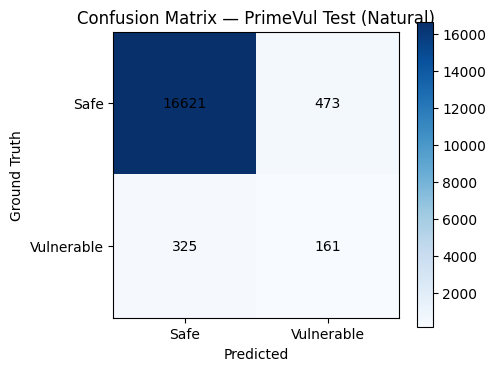

[eval] Starting SECONDARY evaluation on 972 balanced test samples...
SECONDARY — Balanced Test Subset (for comparison to paper's 0.740)
Accuracy: 0.6471 | Precision: 0.8994 | Recall: 0.3313 | F1: 0.4842
SUMMARY
Natural  — Acc: 0.9546 | Prec: 0.2539 | Rec: 0.3313 | F1: 0.2875
Balanced — Acc: 0.6471 | Prec: 0.8994 | Rec: 0.3313 | F1: 0.4842
Paper reference (PrimeVul, QLoRA+head) — F1: 0.740


In [16]:
# ============================================================
# Evaluate — natural test distribution (primary) + balanced subset (vs. paper)
# Uses the tuned threshold from the previous cell.
# ============================================================

def run_eval(texts, labels_list, batch_size=EVAL_BATCH_SIZE, threshold=best_threshold):
    classifier_model.eval()
    preds, true = [], []
    with torch.no_grad():
        for i, start in enumerate(range(0, len(texts), batch_size)):
            b_texts = texts[start:start + batch_size]
            b_labels = labels_list[start:start + batch_size]
            logits, labels_t = batch_forward(b_texts, b_labels)
            p = (torch.sigmoid(logits) > threshold).long().cpu().numpy()
            preds.extend(p)
            true.extend(b_labels)
            if (i + 1) % 200 == 0:
                print(f"  [eval] {i+1}/{len(texts)//batch_size} batches", flush=True)
    return np.array(true), np.array(preds)

print(f"[eval] Starting PRIMARY evaluation on {len(pv_test)} natural-distribution test samples (threshold={best_threshold:.2f})...", flush=True)
test_true, test_preds = run_eval(pv_test["text"], pv_test["label"])
nat_acc = accuracy_score(test_true, test_preds)
nat_prec, nat_rec, nat_f1, _ = precision_recall_fscore_support(test_true, test_preds, average="binary", zero_division=0)

print("=" * 70)
print("PRIMARY — Natural Distribution Test Set")
print("=" * 70)
print(classification_report(test_true, test_preds, target_names=["Safe", "Vulnerable"]))

cm = confusion_matrix(test_true, test_preds)
plt.figure(figsize=(5, 4))
plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix — PrimeVul Test (Natural)")
plt.colorbar()
plt.xticks([0, 1], ["Safe", "Vulnerable"])
plt.yticks([0, 1], ["Safe", "Vulnerable"])
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center", color="black")
plt.xlabel("Predicted")
plt.ylabel("Ground Truth")
plt.tight_layout()
plt.show()

test_labels_arr = np.array(pv_test["label"])
v_idx = np.where(test_labels_arr == 1)[0]
s_idx = np.where(test_labels_arr == 0)[0]
n_bal = min(len(v_idx), len(s_idx))
bal_idx = np.concatenate([rng.choice(v_idx, n_bal, replace=False), rng.choice(s_idx, n_bal, replace=False)])
pv_test_balanced = pv_test.select(bal_idx.tolist())

print(f"[eval] Starting SECONDARY evaluation on {len(pv_test_balanced)} balanced test samples...", flush=True)
bal_true, bal_preds = run_eval(pv_test_balanced["text"], pv_test_balanced["label"])
bal_acc = accuracy_score(bal_true, bal_preds)
bal_prec, bal_rec, bal_f1, _ = precision_recall_fscore_support(bal_true, bal_preds, average="binary", zero_division=0)

print("=" * 70)
print("SECONDARY — Balanced Test Subset (for comparison to paper's 0.740)")
print("=" * 70)
print(f"Accuracy: {bal_acc:.4f} | Precision: {bal_prec:.4f} | Recall: {bal_rec:.4f} | F1: {bal_f1:.4f}")
print("=" * 70)

print("=" * 70)
print("SUMMARY")
print("=" * 70)
print(f"Natural  — Acc: {nat_acc:.4f} | Prec: {nat_prec:.4f} | Rec: {nat_rec:.4f} | F1: {nat_f1:.4f}")
print(f"Balanced — Acc: {bal_acc:.4f} | Prec: {bal_prec:.4f} | Rec: {bal_rec:.4f} | F1: {bal_f1:.4f}")
print(f"Paper reference (PrimeVul, QLoRA+head) — F1: 0.740")
print("=" * 70)

In [17]:
# ============================================================
# Save FINAL model artifact bundle
# ============================================================

model_config = {
    "experiment_name": EXPERIMENT_NAME,
    "run_timestamp": RUN_TIMESTAMP,
    "base_model": BASE_MODEL,
    "hidden_size": model.config.hidden_size,
    "head_hidden_dim": HEAD_HIDDEN_DIM,
    "head_dropout": HEAD_DROPOUT,
    "pooling": POOLING,
    "train_max_length": TRAIN_MAX_LENGTH,
    "lora_rank": LORA_RANK,
    "lora_alpha": LORA_ALPHA,
    "lora_dropout": LORA_DROPOUT,
    "target_modules": TARGET_MODULES,
    "label_names": LABEL_NAMES,
    "vuln_ratio_train": VULN_RATIO_TRAIN,
    "resampling": "dynamic_per_epoch",          # NEW — documents the sampling strategy used
    "use_focal_loss": USE_FOCAL_LOSS,            # NEW
    "focal_gamma": FOCAL_GAMMA if USE_FOCAL_LOSS else None,  # NEW
    "best_epoch": best_epoch,
    "best_val_ap": best_val_ap,          # NEW — PR-AUC used for checkpoint selection
    "checkpoint_selection_metric": "val_ap",   # NEW — documents that PR-AUC drove selection, not F1
    "best_threshold": float(best_threshold),     # NEW — required for correct reload inference
    "primevul_test_accuracy_natural": float(nat_acc),
    "primevul_test_precision_natural": float(nat_prec),   # NEW
    "primevul_test_recall_natural": float(nat_rec),        # NEW
    "primevul_test_f1_natural": float(nat_f1),
    "primevul_test_accuracy_balanced": float(bal_acc),
    "primevul_test_precision_balanced": float(bal_prec),   # NEW
    "primevul_test_recall_balanced": float(bal_rec),        # NEW
    "primevul_test_f1_balanced": float(bal_f1),
    "val_size": len(pv_val),
    "val_monitor_size": len(pv_val_monitor),
    "test_size": len(pv_test),
}

with open(f"{FINAL_MODEL_DIR}/config.json", "w") as f:
    json.dump(model_config, f, indent=2)

with open(f"{FINAL_MODEL_DIR}/training_history.json", "w") as f:
    json.dump(history, f, indent=2)   # history now includes val_precision/val_recall per epoch too

print("=" * 70)
print(f"Final model saved to: {FINAL_MODEL_DIR}")
print("=" * 70)
print(os.listdir(FINAL_MODEL_DIR))
print("=" * 70)

Final model saved to: ./saved_models/primevul_qlora_classifier_v2_resumed
['training_history.json', 'lora_adapter_latest', 'head_latest.pt', 'config.json', 'head_best.pt', 'lora_adapter_best', 'training_state.json']


In [18]:
# ============================================================
# Verify Reload — loads Base model + LoRA adapter + head fresh, confirms matching test metrics
# ============================================================

from peft import PeftModel

reload_base, reload_tokenizer = FastLanguageModel.from_pretrained(
    model_name=BASE_MODEL,
    max_seq_length=MAX_SEQ_LENGTH,
    dtype=DTYPE,
    load_in_4bit=LOAD_IN_4BIT,
    device_map={"": torch.cuda.current_device()},
)
reload_base.config.use_cache = False

reload_peft = PeftModel.from_pretrained(reload_base, f"{FINAL_MODEL_DIR}/lora_adapter_best")

with open(f"{FINAL_MODEL_DIR}/config.json", "r") as f:
    reload_cfg = json.load(f)

reload_classifier = LlamaClassifier(
    reload_peft,
    hidden_size=reload_cfg["hidden_size"],
    head_hidden_dim=reload_cfg["head_hidden_dim"],
    dropout=reload_cfg["head_dropout"],
).to(next(reload_peft.parameters()).device)

reload_classifier.classifier.load_state_dict(
    torch.load(f"{FINAL_MODEL_DIR}/head_best.pt", map_location=reload_classifier.input_device)
)
reload_classifier.eval()

reload_threshold = reload_cfg["best_threshold"]   # NEW — use the saved tuned threshold, not 0.5

def reload_batch_forward(texts, labels_batch):
    encoded = reload_tokenizer(
        texts, return_tensors="pt", padding=True, truncation=True, max_length=reload_cfg["train_max_length"]
    )
    labels_tensor = torch.tensor(labels_batch, dtype=torch.float32).to(reload_classifier.input_device)
    logits = reload_classifier(encoded["input_ids"], encoded["attention_mask"])
    return logits, labels_tensor

preds, true = [], []
with torch.no_grad():
    for start in range(0, len(pv_test["text"]), EVAL_BATCH_SIZE):
        b_texts = pv_test["text"][start:start + EVAL_BATCH_SIZE]
        b_labels = pv_test["label"][start:start + EVAL_BATCH_SIZE]
        logits, labels_t = reload_batch_forward(b_texts, b_labels)
        p = (torch.sigmoid(logits) > reload_threshold).long().cpu().numpy()   # CHANGED — was > 0.5
        preds.extend(p)
        true.extend(b_labels)

reload_acc = accuracy_score(true, preds)
reload_prec, reload_rec, reload_f1, _ = precision_recall_fscore_support(true, preds, average="binary", zero_division=0)

print("=" * 70)
print("Reload Verification (fresh model + adapter + head, loaded from disk)")
print("=" * 70)
print(f"Threshold used                 : {reload_threshold:.2f}")
print(f"Reloaded natural test accuracy  : {reload_acc:.4f}")
print(f"Reloaded natural test precision : {reload_prec:.4f}")
print(f"Reloaded natural test recall    : {reload_rec:.4f}")
print(f"Reloaded natural test F1        : {reload_f1:.4f}")
print("(should closely match nat_acc / nat_prec / nat_rec / nat_f1 from Cell P2-8)")
print("=" * 70)

==((====))==  Unsloth 2026.8.18: Fast Llama patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 2. Max memory: 14.562 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

Unsloth: Will load unsloth/meta-llama-3.1-8b-unsloth-bnb-4bit as a legacy tokenizer.


OutOfMemoryError: CUDA out of memory. Tried to allocate 672.00 MiB. GPU 0 has a total capacity of 14.56 GiB of which 628.81 MiB is free. Including non-PyTorch memory, this process has 13.94 GiB memory in use. Of the allocated memory 13.65 GiB is allocated by PyTorch, and 144.99 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)